# Istanbul Apartment Price Prediction

**Cengizhan Keskin | Python · scikit-learn · XGBoost**

Predict apartment asking prices from location, area and building attributes. This notebook preserves the original modeling workflow and adds explanations, a simple baseline and evaluation charts.

Dataset: [Istanbul Apartment Prices 2026, Enes Ulusoy](https://www.kaggle.com/datasets/brahimenesulusoy/istanbul-apartment-prices-2026). The source matches the supplied filename, schema and listing count.

## 1. Load and inspect the data


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("istanbul_apartment_prices_2026.csv")

In [3]:
df.head()

   listing_id     price  ...  last_updated           scraped_at
0  54895-1121  15900000  ...    2026-03-11  2026-03-14T20:38:29
1  54895-1103  40000000  ...    2026-03-05  2026-03-14T20:38:36
2  54895-1148  17850000  ...    2026-03-05  2026-03-14T20:38:47
3   12854-258  16000000  ...    2026-03-14  2026-03-14T20:38:56
4   121334-99  14000000  ...    2026-03-14  2026-03-14T20:39:04

[5 rows x 30 columns]


In [4]:
df.shape

(24767, 30)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24767 entries, 0 to 24766
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          24767 non-null  object 
 1   price               24767 non-null  int64  
 2   price_per_sqm       24767 non-null  float64
 3   district            24767 non-null  object 
 4   neighborhood        24767 non-null  object 
 5   rooms               24767 non-null  int64  
 6   halls               24767 non-null  int64  
 7   total_rooms         24767 non-null  int64  
 8   gross_sqm           24767 non-null  float64
 9   net_sqm             24767 non-null  float64
 10  floor               22850 non-null  float64
 11  floor_category      7395 non-null   object 
 12  total_floors        24766 non-null  float64
 13  building_age        24767 non-null  int64  
 14  building_type       10206 non-null  object 
 15  building_condition  10920 non-null  object 
 16  heat

In [6]:
df.describe().T

                   count          mean  ...          75%           max
price            24767.0  1.342985e+07  ...  11500000.00  1.150000e+10
price_per_sqm    24767.0  1.326089e+05  ...    113846.15  1.600000e+08
rooms            24767.0  2.577220e+00  ...         3.00  1.140000e+02
halls            24767.0  1.088586e+00  ...         1.00  2.000000e+01
total_rooms      24767.0  3.665805e+00  ...         4.00  1.170000e+02
gross_sqm        24767.0  1.263180e+02  ...       146.00  9.090000e+02
net_sqm          24767.0  1.074915e+02  ...       125.00  9.000000e+02
floor            22850.0  2.800832e+00  ...         4.00  2.000000e+01
total_floors     24766.0  6.623193e+00  ...         7.00  4.500000e+02
building_age     24767.0  1.132955e+01  ...        20.00  4.000000e+02
bathroom_count   24532.0  1.504851e+00  ...         2.00  2.100000e+01
is_in_complex    24767.0  2.239270e-01  ...         0.00  1.000000e+00
maintenance_fee   9002.0  3.778895e+03  ...      1500.00  9.000000e+06

[13 r

In [7]:
df.isnull().sum()

listing_id                0
price                     0
price_per_sqm             0
district                  0
neighborhood              0
rooms                     0
halls                     0
total_rooms               0
gross_sqm                 0
net_sqm                   0
floor                  1917
floor_category        17372
total_floors              1
building_age              0
building_type         14561
building_condition    13847
heating_type              0
fuel_type             13853
bathroom_count          235
furnished              1078
usage_status            634
is_in_complex             0
complex_name          21014
orientation            5316
maintenance_fee       15765
credit_eligible           7
deed_status               1
exchange               1597
last_updated          11893
scraped_at                0
dtype: int64


## 2. Prepare features

Missing maintenance fees are assigned zero, an explicit modeling assumption. `price_per_sqm` is removed because it is derived from the target price; keeping it would leak target information. Listing IDs, timestamps and several sparse fields are also excluded.


In [8]:
df["maintenance_fee"] = df["maintenance_fee"].fillna(0)

In [9]:
df.isnull().sum()

listing_id                0
price                     0
price_per_sqm             0
district                  0
neighborhood              0
rooms                     0
halls                     0
total_rooms               0
gross_sqm                 0
net_sqm                   0
floor                  1917
floor_category        17372
total_floors              1
building_age              0
building_type         14561
building_condition    13847
heating_type              0
fuel_type             13853
bathroom_count          235
furnished              1078
usage_status            634
is_in_complex             0
complex_name          21014
orientation            5316
maintenance_fee           0
credit_eligible           7
deed_status               1
exchange               1597
last_updated          11893
scraped_at                0
dtype: int64


In [10]:
df.columns

Index(['listing_id', 'price', 'price_per_sqm', 'district', 'neighborhood',
       'rooms', 'halls', 'total_rooms', 'gross_sqm', 'net_sqm', 'floor',
       'floor_category', 'total_floors', 'building_age', 'building_type',
       'building_condition', 'heating_type', 'fuel_type', 'bathroom_count',
       'furnished', 'usage_status', 'is_in_complex', 'complex_name',
       'orientation', 'maintenance_fee', 'credit_eligible', 'deed_status',
       'exchange', 'last_updated', 'scraped_at'],
      dtype='object')


In [11]:
df = df.drop(columns=["listing_id","rooms","last_updated","scraped_at","complex_name","price_per_sqm","floor_category","building_type","building_condition","fuel_type"],axis=1)

In [12]:
df.head()

      price district  ...            deed_status  exchange
0  15900000   Adalar  ...             Land Title        No
1  40000000   Adalar  ...  Construction Easement        No
2  17850000   Adalar  ...      Condominium Title        No
3  16000000   Adalar  ...      Condominium Title        No
4  14000000   Adalar  ...      Condominium Title        No

[5 rows x 20 columns]


In [13]:
df.shape

(24767, 20)


In [14]:
for col in df.select_dtypes(exclude="number").columns : 
    uniq_values = df[col].unique()
    print("COLUMN NAME: ",col)
    print(uniq_values)
    print("--------------------------------------------------------------------------")

COLUMN NAME:  district
['Adalar' 'Arnavutköy' 'Ataşehir' 'Avcılar' 'Bağcılar' 'Bahçelievler'
 'Bakırköy' 'Başakşehir' 'Bayrampaşa' 'Beşiktaş' 'Beykoz' 'Beylikdüzü'
 'Beyoğlu' 'Büyükçekmece' 'Çatalca' 'Çekmeköy' 'Esenler' 'Esenyurt'
 'Eyüpsultan' 'Gaziosmanpaşa' 'Şişli' 'Sancaktepe' 'Kadıköy' 'Sarıyer'
 'Üsküdar' 'Küçükçekmece' 'Kartal' 'Maltepe' 'Fatih' 'Güngören'
 'Kağıthane' 'Pendik' 'Silivri' 'Sultanbeyli' 'Sultangazi' 'Tuzla'
 'Ümraniye' 'Zeytinburnu']
--------------------------------------------------------------------------
COLUMN NAME:  neighborhood
['Maden' 'Nizam' 'Heybeliada' 'Kınalıada' 'Burgazada' 'İslambey'
 'Karlıbayır' 'Adnan Menderes' 'Anadolu' 'Nenehatun' 'Hadımköy' 'Haraççı'
 'Hicret' 'Mustafa Kemal Paşa' 'Deliklikaya' 'Mehmet Akif Ersoy' 'Taşoluk'
 'Atatürk' 'Sazlıbosna' 'Arnavutköy Merkez' 'Boğazköy İstiklal' 'Mavigöl'
 'Ömerli' 'Hastane' 'Dursunköy' 'Bolluca' 'Yunus Emre' 'Baklalı'
 'Yassıören' 'Fatih' 'Yavuz Selim' 'Mareşal Fevzi Çakmak' 'İçerenköy'
 'Örnek' 'Feti

In [15]:
df.isnull().sum()

price                 0
district              0
neighborhood          0
halls                 0
total_rooms           0
gross_sqm             0
net_sqm               0
floor              1917
total_floors          1
building_age          0
heating_type          0
bathroom_count      235
furnished          1078
usage_status        634
is_in_complex         0
orientation        5316
maintenance_fee       0
credit_eligible       7
deed_status           1
exchange           1597
dtype: int64


In [16]:
df["orientation"].value_counts()

orientation
South                       4682
South, East                 3381
South, East, West           2418
North, South, East, West    2027
South, West                 1533
North, South                 957
East                         836
East, West                   802
West                         544
North, South, East           447
North, East                  440
North, West                  409
North                        360
North, East, West            307
North, South, West           307
Fourplex                       1
Name: count, dtype: int64


In [17]:
df.shape

(24767, 20)


## 3. Define the modeled price segment

Keep prices within Q1 − 3×IQR and Q3 + 3×IQR, then keep maintenance fees below 5,000 TRY. These rules preserve the original experiment. **The IQR bounds are computed before the split, so the held-out target distribution influences sample selection.** Results describe this filtered sample, not the entire Istanbul market. A future evaluation should split first and learn any data-dependent filtering on training data only.


In [18]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 3* IQR
upper_bound = Q3 + 3* IQR

df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

In [19]:
df.shape

(23565, 20)


In [20]:
df["maintenance_fee"].max()

9000000.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23565 entries, 0 to 24766
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            23565 non-null  int64  
 1   district         23565 non-null  object 
 2   neighborhood     23565 non-null  object 
 3   halls            23565 non-null  int64  
 4   total_rooms      23565 non-null  int64  
 5   gross_sqm        23565 non-null  float64
 6   net_sqm          23565 non-null  float64
 7   floor            21827 non-null  float64
 8   total_floors     23564 non-null  float64
 9   building_age     23565 non-null  int64  
 10  heating_type     23565 non-null  object 
 11  bathroom_count   23337 non-null  float64
 12  furnished        22591 non-null  object 
 13  usage_status     22993 non-null  object 
 14  is_in_complex    23565 non-null  int64  
 15  orientation      18528 non-null  object 
 16  maintenance_fee  23565 non-null  float64
 17  credit_eligible  

In [22]:
df = df[df["maintenance_fee"]<5000]

In [23]:
df.shape

(22995, 20)


## 4. Split data and build the pipeline

Use a 75% training / 25% test split with seed 42. Numeric features use median imputation. Categorical features use most-frequent imputation and cross-fitted target encoding (`cv=5`). Preprocessing is fitted within the training pipeline. The five folds belong to target encoding; they are **not** five-fold evaluation of the final model.


In [24]:
from sklearn.preprocessing import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [25]:
X=df.drop("price",axis=1)
y=df["price"]

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [27]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

In [28]:
numeric_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median"))
])
categoric_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("targetencoder",TargetEncoder(target_type="continuous",smooth="auto",cv=5,shuffle=True,random_state=42)
)
])
preprocessor = ColumnTransformer([
    ("numeric",numeric_pipeline,numerical_cols),
    ("categoric",categoric_pipeline,categorical_cols)
])

## 5. Train XGBoost

The original model uses XGBoost defaults without a hyperparameter search.


In [29]:
model_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBRegressor())
])

In [30]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['halls', 'total_rooms',
                                                   'gross_sqm', 'net_sqm',
                                                   'floor', 'total_floors',
                                                   'building_age',
                                                   'bathroom_count',
                                                   'is_in_complex',
                                                   'maintenance_fee']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(

## 6. Evaluate on held-out listings

R² measures explained variation, not percentage accuracy. MAE and RMSE are expressed in TRY.


In [31]:
y_pred = model_pipeline.predict(X_test)

In [32]:
print("R2 SCORE : ",r2_score(y_test,y_pred))
print()

R2 SCORE :  0.8221765756607056



In [33]:
print("Eğitim fiyat dağılımı:")
print(y_train.describe(percentiles=[0.5, 0.95, 0.99]))

print("\nTest fiyat dağılımı:")
print(y_test.describe(percentiles=[0.5, 0.95, 0.99]))

print("\nTahmin aralığı:", np.min(y_pred), np.max(y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Eğitim fiyat dağılımı:
count    1.724600e+04
mean     8.276839e+06
std      5.891852e+06
min      2.400000e+04
50%      6.500000e+06
95%      2.195000e+07
99%      2.925000e+07
max      3.250000e+07
Name: price, dtype: float64

Test fiyat dağılımı:
count    5.749000e+03
mean     8.310788e+06
std      5.924297e+06
min      3.800000e+04
50%      6.500000e+06
95%      2.150000e+07
99%      2.950000e+07
max      3.250000e+07
Name: price, dtype: float64

Tahmin aralığı: 553177.7 3.1550916e+07
MAE: 1619965.125
R²: 0.8221765756607056


## 7. Save the fitted pipeline

The artifact contains both preprocessing and the regressor. Run the notebook to regenerate it in your environment. Only load pickle files from sources you trust.


In [34]:
import pickle

In [35]:
with open("houseprice.pkl","wb") as f:
    pickle.dump(model_pipeline,f)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22995 entries, 0 to 24766
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            22995 non-null  int64  
 1   district         22995 non-null  object 
 2   neighborhood     22995 non-null  object 
 3   halls            22995 non-null  int64  
 4   total_rooms      22995 non-null  int64  
 5   gross_sqm        22995 non-null  float64
 6   net_sqm          22995 non-null  float64
 7   floor            21299 non-null  float64
 8   total_floors     22994 non-null  float64
 9   building_age     22995 non-null  int64  
 10  heating_type     22995 non-null  object 
 11  bathroom_count   22770 non-null  float64
 12  furnished        22040 non-null  object 
 13  usage_status     22433 non-null  object 
 14  is_in_complex    22995 non-null  int64  
 15  orientation      18052 non-null  object 
 16  maintenance_fee  22995 non-null  float64
 17  credit_eligible  

## 8. Compare with a simple baseline

A mean-price predictor provides a reference on the same split. The chart shows both model performance and remaining error; no additional tuning uses the test set.


In [37]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error
import json
from pathlib import Path

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
results = pd.DataFrame({
    "Model": ["Mean baseline", "XGBoost"],
    "R2": [r2_score(y_test, baseline_pred), r2_score(y_test, y_pred)],
    "MAE_TRY": [mean_absolute_error(y_test, baseline_pred), mean_absolute_error(y_test, y_pred)],
    "RMSE_TRY": [root_mean_squared_error(y_test, baseline_pred), root_mean_squared_error(y_test, y_pred)],
})
print(results.to_string(index=False))
Path("reports").mkdir(exist_ok=True)
results.to_csv("reports/model_comparison.csv", index=False)
metrics = {
    "raw_rows": 24767, "modeled_rows": len(df), "features": X.shape[1],
    "train_rows": len(X_train), "test_rows": len(X_test),
    "split_seed": 42, "test_size": 0.25,
    "price_filter_lower": float(lower_bound), "price_filter_upper": float(upper_bound),
    "results": results.to_dict(orient="records"),
}
Path("reports/metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")


        Model        R2      MAE_TRY     RMSE_TRY
Mean baseline -0.000033 4.345701e+06 5.923879e+06
      XGBoost  0.822177 1.619965e+06 2.498006e+06
524


HouseProject.ipynb:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "cell_type": "code",


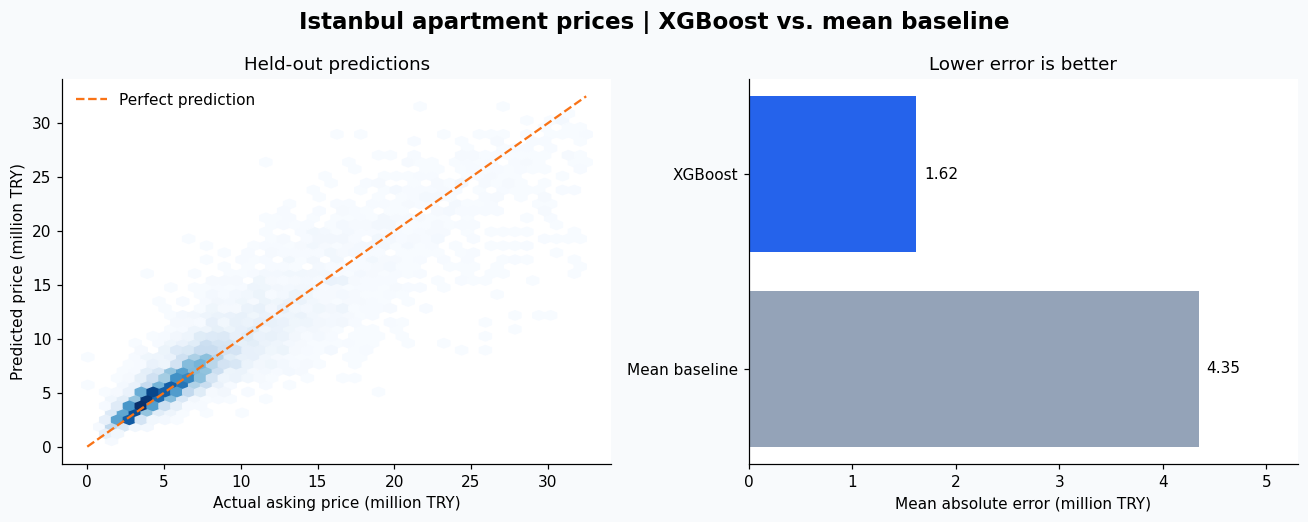

In [38]:
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
fig.set_facecolor("#f8fafc")
axes[0].hexbin(y_test / 1e6, y_pred / 1e6, gridsize=42, mincnt=1, cmap="Blues")
limit = max(float(y_test.max()), float(y_pred.max())) / 1e6
axes[0].plot([0, limit], [0, limit], "--", color="#f97316", linewidth=1.5, label="Perfect prediction")
axes[0].set(xlabel="Actual asking price (million TRY)", ylabel="Predicted price (million TRY)", title="Held-out predictions")
axes[0].legend(frameon=False)
bars = axes[1].barh(results["Model"], results["MAE_TRY"] / 1e6, color=["#94a3b8", "#2563eb"])
axes[1].bar_label(bars, fmt="%.2f", padding=5)
axes[1].set(xlabel="Mean absolute error (million TRY)", title="Lower error is better")
axes[1].set_xlim(0, results["MAE_TRY"].max() / 1e6 * 1.22)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Istanbul apartment prices | XGBoost vs. mean baseline", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig("reports/evaluation.png", dpi=170, bbox_inches="tight")
plt.show()


## Interpretation and next steps

- This is a learning project using asking prices, not verified transaction prices.
- Random row splitting does not rule out duplicate or near-duplicate property leakage, or establish performance on future listings.
- The price and maintenance filters exclude expensive market segments. Pre-split price filtering is a limitation of this experiment.
- Unknown maintenance fees are treated as zero; this may introduce bias.
- Next steps: split before estimating filters, audit duplicate properties, evaluate by district and time, and compare tuned models using training-only validation.
